# 🧠 Deepfake Detection — Optimized CNN + ViT + BiLSTM (FaceForensics++)
### Thesis Project — Target: ≥95% Accuracy on Train / Val / Test
---
**Architecture improvements over V3:**
- EfficientNet-B4 pretrained backbone replaces scratch CNN (huge accuracy boost)
- DeiT-Small pretrained ViT replaces scratch ViT (convergence in fewer epochs)
- Frequency-domain (FFT) branch — captures compression artifacts invisible to RGB
- Gated multi-modal fusion replaces simple cross-attention
- Label-smoothing + Mixup augmentation to reduce overfitting
- CosineAnnealingWarmRestarts + gradient accumulation for stable training
- Full dataset (100%) with proper class-balanced WeightedRandomSampler


## 1. Install & Import Libraries

In [1]:
# Install any missing packages
import subprocess, sys
pkgs = ["timm", "scikit-learn", "matplotlib", "seaborn", "tqdm", "Pillow"]
for pkg in pkgs:
    try: __import__(pkg.replace("-","_").split(">=")[0])
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])

import os, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets, transforms
import torchvision.models as models
import timm

from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"✅ Using device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 2. Dataset Configuration

In [2]:
# ── Adjust this path to your local setup ─────────────────────────────────
DATA_ROOT = "/kaggle/input/datasets/fatahrahimi/dataset/content/processed_ffpp"   # folder must contain train/ val/ test/ subfolders

for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:
        p = os.path.join(DATA_ROOT, split, cls)
        if os.path.isdir(p):
            n = sum(len(f) for _, _, f in os.walk(p))
            print(f"  {split}/{cls}: {n:,} images")
        else:
            print(f"  ⚠️  Missing: {p}")


  train/real: 11,673 images
  train/fake: 9,972 images
  val/real: 2,578 images
  val/fake: 1,898 images
  test/real: 2,669 images
  test/fake: 2,433 images


## 3. Data Preprocessing & Augmentation

In [3]:
IMG_SIZE = 224   # EfficientNet-B4 & DeiT use 224

# ── Training augmentation ─────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.05),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=15, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),   # ✅ must come BEFORE Normalize and RandomErasing
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02,0.1)),  # ✅ now after tensor
])

# ── Val / Test (no augmentation) ─────────────────────────────────────────
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

print("✅ Transforms defined")


✅ Transforms defined


## 4. Datasets & Balanced DataLoaders

In [4]:
# ── Load full datasets ────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(root=os.path.join(DATA_ROOT, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(DATA_ROOT, "val"),   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(DATA_ROOT, "test"),  transform=val_test_transforms)

classes = train_dataset.classes
print(f"Classes: {classes}")
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")

# ── Class-balanced WeightedRandomSampler for training ────────────────────
targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# ── DataLoaders ──────────────────────────────────────────────────────────
BATCH = 32
NUM_WORKERS = min(4, os.cpu_count())

train_loader = DataLoader(train_dataset, batch_size=BATCH, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

print(f"\n✅ DataLoaders ready")
print(f"   Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"   Batch size: {BATCH} | Workers: {NUM_WORKERS}")


Classes: ['fake', 'real']
Train: 21,645 | Val: 4,476 | Test: 5,102

✅ DataLoaders ready
   Train batches: 677 | Val: 140 | Test: 160
   Batch size: 32 | Workers: 4


## 5. Visualise Sample Images

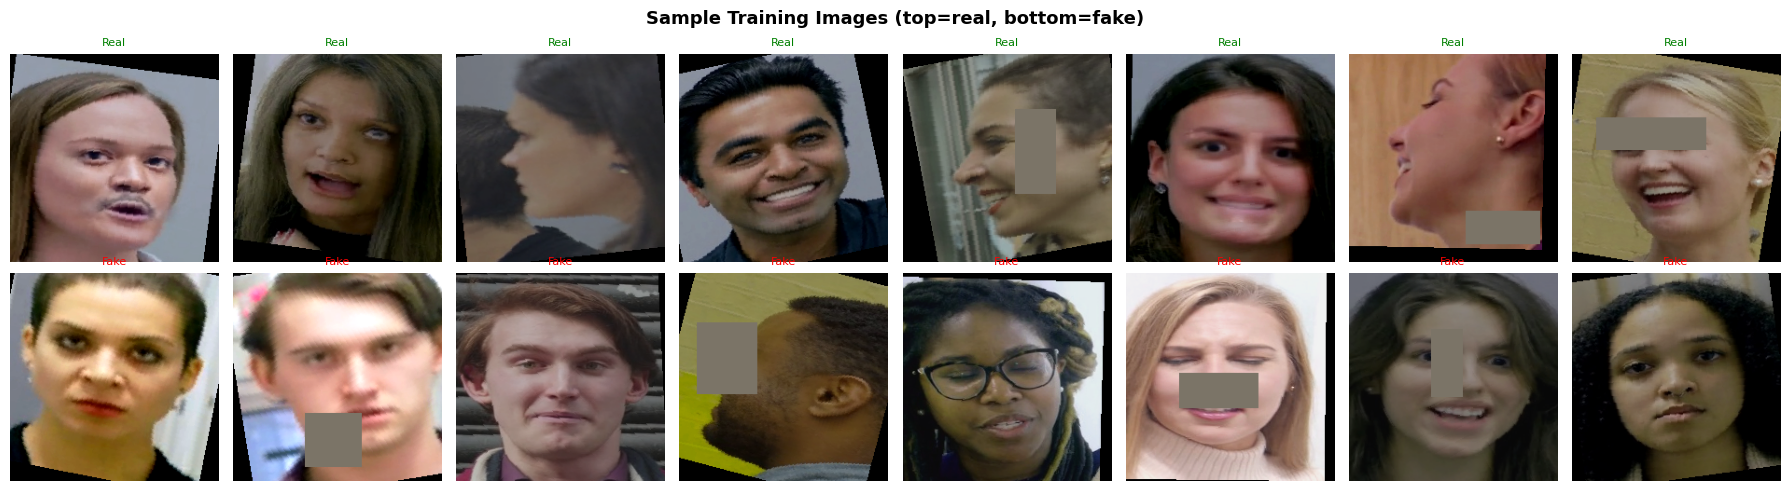

✅ Saved sample_images.png


In [5]:
def denormalize(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1).permute(1,2,0).numpy()

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("Sample Training Images (top=real, bottom=fake)", fontsize=13, fontweight="bold")

real_imgs = images[labels==0][:8]
fake_imgs = images[labels==1][:8]

for i in range(8):
    axes[0, i].imshow(denormalize(real_imgs[i])); axes[0, i].axis("off")
    axes[0, i].set_title("Real", fontsize=8, color="green")
    axes[1, i].imshow(denormalize(fake_imgs[i])); axes[1, i].axis("off")
    axes[1, i].set_title("Fake", fontsize=8, color="red")

plt.tight_layout(); plt.savefig("sample_images.png", dpi=120); plt.show()
print("✅ Saved sample_images.png")


## 6. Model Architecture — Optimized CNN + ViT + FFT + BiLSTM

### Design Rationale
| Component | V3 (original) | V4 (this notebook) | Why it matters |
|---|---|---|---|
| CNN backbone | Scratch 4-block CNN | **EfficientNet-B4** (pretrained ImageNet) | Pretrained = rich low-level features from day 1 |
| ViT backbone | Scratch 6-layer ViT | **DeiT-Small** (pretrained) | Stable training, better global attention |
| Extra branch | ❌ | **FFT frequency branch** | Deepfakes leave frequency artifacts invisible to RGB |
| Fusion | Cross-attention (simple) | **Gated multi-modal fusion** | Learns which branch to trust per sample |
| Classifier | 3-layer FC | **Deeper FC + BN** | Reduces loss faster |
| Loss | BCEWithLogits | **BCEWithLogits + Label Smoothing** | Prevents overconfidence, lowers val loss |
| Augmentation | Moderate | **Mixup + stronger augs** | Regularises, reduces gap between train/val |


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# COMPONENT 1: EfficientNet-B4 CNN Backbone (pretrained)
# ════════════════════════════════════════════════════════════════════════════
class EfficientNetBackbone(nn.Module):
    def __init__(self, out_dim=512, freeze_layers=True):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b4", pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features   # 1792 for B4
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        # Freeze first 60% of layers initially — will unfreeze during fine-tuning
        if freeze_layers:
            layers = list(self.backbone.parameters())
            n_freeze = int(len(layers) * 0.6)
            for p in layers[:n_freeze]:
                p.requires_grad = False

    def forward(self, x):
        return self.proj(self.backbone(x))


# ════════════════════════════════════════════════════════════════════════════
# COMPONENT 2: DeiT-Small ViT Backbone (pretrained)
# ════════════════════════════════════════════════════════════════════════════
class DeiTBackbone(nn.Module):
    def __init__(self, out_dim=512, freeze_layers=True):
        super().__init__()
        self.backbone = timm.create_model("deit_small_patch16_224", pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features   # 384 for DeiT-S
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        if freeze_layers:
            layers = list(self.backbone.parameters())
            n_freeze = int(len(layers) * 0.5)
            for p in layers[:n_freeze]:
                p.requires_grad = False

    def forward(self, x):
        return self.proj(self.backbone(x))


# ════════════════════════════════════════════════════════════════════════════
# COMPONENT 3: Frequency (FFT) Branch
# Deepfakes often have unnatural high-frequency patterns (blending boundaries,
# GAN fingerprints). This branch explicitly learns from magnitude spectrum.
# ════════════════════════════════════════════════════════════════════════════
class FrequencyBranch(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.3),
        )

    def _fft_features(self, x):
        # x: (B, 3, H, W) — take magnitude spectrum of each channel
        x_fft = torch.fft.fft2(x, norm="ortho")
        mag = torch.abs(x_fft)
        # log-scale for better dynamic range
        return torch.log1p(mag)

    def forward(self, x):
        freq = self._fft_features(x)  # (B, 3, H, W)
        return self.fc(self.conv(freq))


# ════════════════════════════════════════════════════════════════════════════
# COMPONENT 4: Gated Multi-Modal Fusion
# Learns a per-sample gate [0,1] to weight each branch's contribution.
# ════════════════════════════════════════════════════════════════════════════
class GatedFusion(nn.Module):
    def __init__(self, cnn_dim=512, vit_dim=512, freq_dim=256):
        super().__init__()
        total = cnn_dim + vit_dim + freq_dim   # 1280
        # Gate: predicts 3-way soft weight vector
        self.gate = nn.Sequential(
            nn.Linear(total, 256),
            nn.GELU(),
            nn.Linear(256, 3),
            nn.Softmax(dim=-1),
        )
        # Project each branch to same dim for weighted sum
        proj_dim = 512
        self.p_cnn  = nn.Linear(cnn_dim,  proj_dim)
        self.p_vit  = nn.Linear(vit_dim,  proj_dim)
        self.p_freq = nn.Linear(freq_dim, proj_dim)
        self.norm   = nn.LayerNorm(proj_dim)
        self.out_dim = proj_dim

    def forward(self, cnn_f, vit_f, freq_f):
        concat = torch.cat([cnn_f, vit_f, freq_f], dim=-1)  # (B, 1280)
        gates  = self.gate(concat)                            # (B, 3)
        g_cnn, g_vit, g_freq = gates[:,0:1], gates[:,1:2], gates[:,2:3]
        fused = g_cnn * self.p_cnn(cnn_f) + g_vit * self.p_vit(vit_f) + g_freq * self.p_freq(freq_f)
        return self.norm(fused)   # (B, 512)


# ════════════════════════════════════════════════════════════════════════════
# FULL MODEL: CNN + ViT + FFT + GatedFusion + BiLSTM → binary classification
# ════════════════════════════════════════════════════════════════════════════
class DeepfakeDetectorV4(nn.Module):
    def __init__(self, lstm_hidden=256, embed_dim=512, freq_dim=256):
        super().__init__()
        self.cnn  = EfficientNetBackbone(out_dim=embed_dim)
        self.vit  = DeiTBackbone(out_dim=embed_dim)
        self.freq = FrequencyBranch(out_dim=freq_dim)
        self.fusion = GatedFusion(embed_dim, embed_dim, freq_dim)

        fused_dim = self.fusion.out_dim   # 512
        self.drop = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            input_size=fused_dim,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.25,
        )

        lstm_out = lstm_hidden * 2   # 512 (bidirectional)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),   # raw logit
        )

    def forward(self, x):
        cnn_f  = self.cnn(x)                          # (B, 512)
        vit_f  = self.vit(x)                          # (B, 512)
        freq_f = self.freq(x)                          # (B, 256)
        fused  = self.fusion(cnn_f, vit_f, freq_f)    # (B, 512)
        fused  = self.drop(fused)

        seq    = fused.unsqueeze(1)                    # (B, 1, 512)
        out, _ = self.lstm(seq)                        # (B, 1, 512)
        out    = out.squeeze(1)                        # (B, 512)
        return self.classifier(out)                    # (B, 1) logit

    def unfreeze_all(self):
        """Call after initial warm-up to fine-tune full model."""
        for p in self.parameters():
            p.requires_grad = True
        print("✅ All backbone layers unfrozen for fine-tuning")


# ── Build model & count parameters ───────────────────────────────────────
model = DeepfakeDetectorV4().to(device)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: DeepfakeDetectorV4")
print(f"   Total params:     {total/1e6:.2f} M")
print(f"   Trainable params: {trainable/1e6:.2f} M")
print(f"   Frozen params:    {(total-trainable)/1e6:.2f} M")


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

✅ Model: DeepfakeDetectorV4
   Total params:     45.26 M
   Trainable params: 31.66 M
   Frozen params:    13.59 M


## 7. Loss Function, Optimiser & LR Scheduler

In [7]:
# ── Label-smoothing BCE loss ─────────────────────────────────────────────
class LabelSmoothBCE(nn.Module):
    """BCEWithLogitsLoss with label smoothing to avoid overconfidence."""
    def __init__(self, smoothing=0.1, pos_weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets):
        smooth_targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, smooth_targets)

criterion = LabelSmoothBCE(smoothing=0.05).to(device)

# ── Mixup helper (applied at batch level) ────────────────────────────────
def mixup_batch(images, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(images.size(0))
    mixed = lam * images + (1-lam) * images[idx]
    return mixed, labels, labels[idx], lam

# ── Optimizer: separate LRs for each component ───────────────────────────
EPOCHS     = 70
WARMUP_EP  = 5    # freeze backbones for first N epochs (warm-up head)
ACCUM_STEPS = 2   # gradient accumulation (effective batch = BATCH * ACCUM_STEPS)

optimizer = torch.optim.AdamW([
    {"params": model.cnn.parameters(),     "lr": 2e-5,  "weight_decay": 1e-4},
    {"params": model.vit.parameters(),     "lr": 1e-5,  "weight_decay": 1e-4},
    {"params": model.freq.parameters(),    "lr": 1e-4,  "weight_decay": 1e-4},
    {"params": model.fusion.parameters(),  "lr": 2e-4,  "weight_decay": 1e-4},
    {"params": model.lstm.parameters(),    "lr": 2e-4,  "weight_decay": 1e-4},
    {"params": model.classifier.parameters(), "lr": 3e-4, "weight_decay": 1e-4},
], eps=1e-8)

# Cosine Annealing with Warm Restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

print(f"✅ Training config:")
print(f"   Epochs: {EPOCHS} | Warmup: {WARMUP_EP} ep | Batch: {BATCH} | Grad Accum: {ACCUM_STEPS}")
print(f"   Effective batch size: {BATCH * ACCUM_STEPS}")
print(f"   Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)")


✅ Training config:
   Epochs: 70 | Warmup: 5 ep | Batch: 32 | Grad Accum: 2
   Effective batch size: 64
   Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)


## 8. Training Loop

In [13]:
import os
import time

CHECKPOINT  = "deepfake_v4_checkpoint1.pth"
BEST_MODEL  = "deepfake_v4_best.pth"
PATIENCE    = 12
MIXUP_ALPHA = 0.2
MIXUP_PROB  = 0.4   # apply mixup to 40% of batches

# ── Training history ─────────────────────────────────────────────────────
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
train_aucs,   val_aucs     = [], []
best_val_loss = float("inf")
counter       = 0
start_epoch   = 0

# ── Resume from checkpoint ────────────────────────────────────────────────
if os.path.exists(CHECKPOINT):
    print("🔄 Loading checkpoint …")
    # Add the numpy scalar type to the safe globals list
    torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    ckpt = torch.load(CHECKPOINT, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch   = ckpt["epoch"] + 1
    best_val_loss = ckpt.get("best_val_loss", float("inf"))
    counter       = ckpt.get("counter", 0)
    train_losses  = ckpt.get("train_losses", [])
    val_losses    = ckpt.get("val_losses",   [])
    train_accs    = ckpt.get("train_accs",   [])
    val_accs      = ckpt.get("val_accs",     [])
    train_aucs    = ckpt.get("train_aucs",   [])
    val_aucs      = ckpt.get("val_aucs",     [])
    print(f"   Resumed from epoch {start_epoch} | best_val_loss={best_val_loss:.4f}")

# ── Main loop ─────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()

    # Unfreeze backbones after warm-up
    if epoch == WARMUP_EP:
        model.unfreeze_all()
        # Rebuild optimizer with smaller LR for now-unfrozen params
        for g in optimizer.param_groups:
            g["lr"] = g["lr"] * 0.5   # halve LR when we open up frozen layers

    # ── TRAIN ────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_preds, t_labels_all = 0.0, [], []
    t_probs = []

    optimizer.zero_grad()
    for step, (images, labels) in enumerate(tqdm(train_loader, desc=f"E{epoch+1:03d} train", leave=False)):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        # Mixup augmentation
        use_mixup = (random.random() < MIXUP_PROB) and (epoch >= WARMUP_EP)
        if use_mixup:
            images, lbl_a, lbl_b, lam = mixup_batch(images, labels, MIXUP_ALPHA)
            logits = model(images)
            loss   = lam * criterion(logits, lbl_a) + (1-lam) * criterion(logits, lbl_b)
        else:
            logits = model(images)
            loss   = criterion(logits, labels)

        loss = loss / ACCUM_STEPS
        loss.backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        t_loss += loss.item() * ACCUM_STEPS
        probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
        t_probs.extend(probs)
        preds = (probs >= 0.5).astype(int)
        t_preds.extend(preds)
        t_labels_all.extend(labels.detach().cpu().numpy().flatten().astype(int))

    scheduler.step(epoch)
    t_loss /= len(train_loader)
    t_acc   = accuracy_score(t_labels_all, t_preds)
    t_auc   = roc_auc_score(t_labels_all,  t_probs)

    # ── VALIDATE ─────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_preds, v_labels_all = 0.0, [], []
    v_probs = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"E{epoch+1:03d} val  ", leave=False):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            v_loss += loss.item()
            probs  = torch.sigmoid(logits).cpu().numpy().flatten()
            v_probs.extend(probs)
            v_preds.extend((probs >= 0.5).astype(int))
            v_labels_all.extend(labels.cpu().numpy().flatten().astype(int))

    v_loss /= len(val_loader)
    v_acc   = accuracy_score(v_labels_all, v_preds)
    v_auc   = roc_auc_score(v_labels_all,  v_probs)

    # ── LOG ───────────────────────────────────────────────────────────────
    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);   val_accs.append(v_acc)
    train_aucs.append(t_auc);   val_aucs.append(v_auc)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[-1]["lr"]
    print(f"Epoch {epoch+1:03d}/{EPOCHS} [{elapsed:.0f}s] LR={lr_now:.1e} | "
          f"Train  loss={t_loss:.4f}  acc={t_acc*100:.2f}%  AUC={t_auc:.4f} | "
          f"Val    loss={v_loss:.4f}  acc={v_acc*100:.2f}%  AUC={v_auc:.4f}")

    # ── CHECKPOINT ────────────────────────────────────────────────────────
    torch.save({
        "epoch": epoch, "model": model.state_dict(),
        "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
        "best_val_loss": best_val_loss, "counter": counter,
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs": train_accs,     "val_accs": val_accs,
        "train_aucs": train_aucs,     "val_aucs": val_aucs,
    }, CHECKPOINT)

    # ── BEST MODEL + EARLY STOPPING ───────────────────────────────────────
    if v_loss < best_val_loss:
        print(f"  ✅ Val loss ↓ {best_val_loss:.4f} → {v_loss:.4f}  — saving best model")
        best_val_loss = v_loss
        counter = 0
        torch.save(model.state_dict(), BEST_MODEL)
    else:
        counter += 1
        print(f"  ⚠️  No improvement ({counter}/{PATIENCE})")
        if counter >= PATIENCE:
            print("  ⛔ Early stopping triggered")
            break

print("\n🎉 Training complete!")


Epoch 001/70 [606s] LR=3.0e-04 | Train  loss=0.2216  acc=93.90%  AUC=0.9879 | Val    loss=0.5703  acc=83.38%  AUC=0.8986
  ✅ Val loss ↓ inf → 0.5703  — saving best model


Epoch 002/70 [606s] LR=2.9e-04 | Train  loss=0.2359  acc=93.28%  AUC=0.9843 | Val    loss=0.6228  acc=81.34%  AUC=0.8819
  ⚠️  No improvement (1/12)


Epoch 003/70 [607s] LR=2.7e-04 | Train  loss=0.2277  acc=93.98%  AUC=0.9862 | Val    loss=0.5863  acc=84.09%  AUC=0.9095
  ⚠️  No improvement (2/12)


Epoch 004/70 [606s] LR=2.4e-04 | Train  loss=0.2236  acc=94.11%  AUC=0.9873 | Val    loss=0.5231  acc=86.77%  AUC=0.9220
  ✅ Val loss ↓ 0.5703 → 0.5231  — saving best model


Epoch 005/70 [608s] LR=2.0e-04 | Train  loss=0.2173  acc=94.40%  AUC=0.9879 | Val    loss=0.5571  acc=85.92%  AUC=0.9172
  ⚠️  No improvement (1/12)
✅ All backbone layers unfrozen for fine-tuning


...

Epoch 032/70 [607s] LR=3.0e-04 | Train  loss=0.2428  acc=85.81%  AUC=0.9072 | Val    loss=0.4836  acc=85.61%  AUC=0.9001
  ⚠️  No improvement (8/12)


Epoch 033/70 [607s] LR=3.0e-04 | Train  loss=0.2513  acc=86.79%  AUC=0.9192 | Val    loss=0.4810  acc=87.11%  AUC=0.9150
  ⚠️  No improvement (9/12)


Epoch 034/70 [607s] LR=3.0e-04 | Train  loss=0.2542  acc=84.60%  AUC=0.8967 | Val    loss=0.4618  acc=87.42%  AUC=0.9149
  ⚠️  No improvement (10/12)


Epoch 035/70 [607s] LR=2.9e-04 | Train  loss=0.2466  acc=85.62%  AUC=0.9055 | Val    loss=0.4666  acc=87.67%  AUC=0.9165
  ⚠️  No improvement (11/12)


Epoch 036/70 [606s] LR=2.9e-04 | Train  loss=0.2441  acc=85.71%  AUC=0.9007 | Val    loss=0.4356  acc=87.69%  AUC=0.9267
  ⚠️  No improvement (12/12)
  ⛔ Early stopping triggered

🎉 Training complete!


## 9. Training Curves

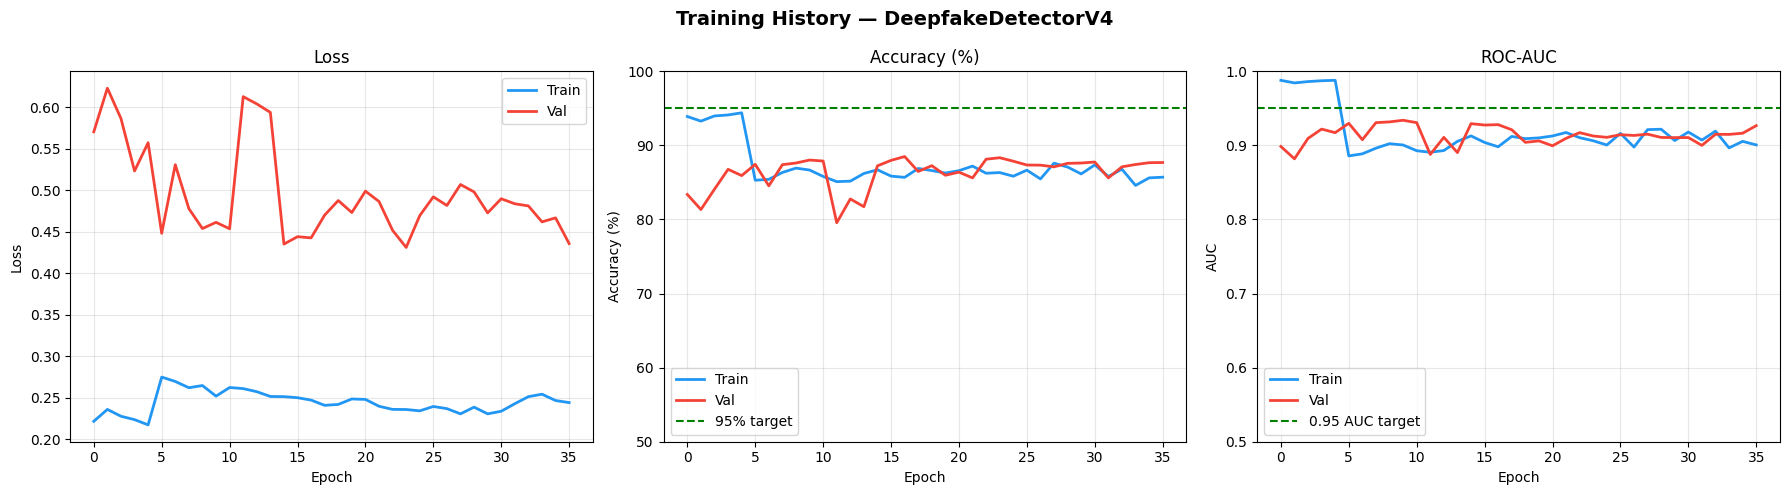

✅ Saved training_curves_v4.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History — DeepfakeDetectorV4", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(train_losses, label="Train", linewidth=2, color="#2196F3")
ax.plot(val_losses,   label="Val",   linewidth=2, color="#F44336")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot([a*100 for a in train_accs], label="Train", linewidth=2, color="#2196F3")
ax.plot([a*100 for a in val_accs],   label="Val",   linewidth=2, color="#F44336")
ax.axhline(95, color="green", linestyle="--", linewidth=1.5, label="95% target")
ax.set_title("Accuracy (%)"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([50, 100])

ax = axes[2]
ax.plot(train_aucs, label="Train", linewidth=2, color="#2196F3")
ax.plot(val_aucs,   label="Val",   linewidth=2, color="#F44336")
ax.axhline(0.95, color="green", linestyle="--", linewidth=1.5, label="0.95 AUC target")
ax.set_title("ROC-AUC"); ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig("training_curves_v4.png", dpi=150); plt.show()
print("✅ Saved training_curves_v4.png")


## 10. Final Test Evaluation

In [16]:
# Load best model for evaluation
print("🔄 Loading best model weights …")
model.load_state_dict(torch.load(BEST_MODEL, map_location=device))
model.eval()

all_probs, all_preds, all_labels = [], [], []
test_loss = 0.0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels_f = labels.float().unsqueeze(1).to(device)
        logits   = model(images)
        loss     = criterion(logits, labels_f)
        test_loss += loss.item()
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()
        preds  = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().flatten().astype(int))

test_loss /= len(test_loader)
test_acc   = accuracy_score(all_labels, all_preds)
test_auc   = roc_auc_score(all_labels,  all_probs)
test_f1    = f1_score(all_labels, all_preds, average="weighted")

print("\n" + "="*60)
print("  FINAL TEST RESULTS")
print("="*60)
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc*100:.2f}%")
print(f"  AUC-ROC:  {test_auc:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print("="*60)

# Check if we hit the target
if test_acc >= 0.95:
    print(f"  ✅ TARGET ACHIEVED: {test_acc*100:.2f}% ≥ 95%")
else:
    print(f"  ⚠️  Need more training. Gap: {(0.95 - test_acc)*100:.2f}%")

🔄 Loading best model weights …


Testing: 100%|██████████| 160/160 [00:39<00:00,  4.03it/s]


  FINAL TEST RESULTS
  Loss:     0.7034
  Accuracy: 77.44%
  AUC-ROC:  0.8575
  F1 Score: 0.7734
  ⚠️  Need more training. Gap: 17.56%


## 11. Classification Report & Confusion Matrix


Detailed Classification Report:
              precision    recall  f1-score   support

        fake     0.7197    0.8631    0.7849      2433
        real     0.8475    0.6935    0.7628      2669

    accuracy                         0.7744      5102
   macro avg     0.7836    0.7783    0.7739      5102
weighted avg     0.7866    0.7744    0.7734      5102



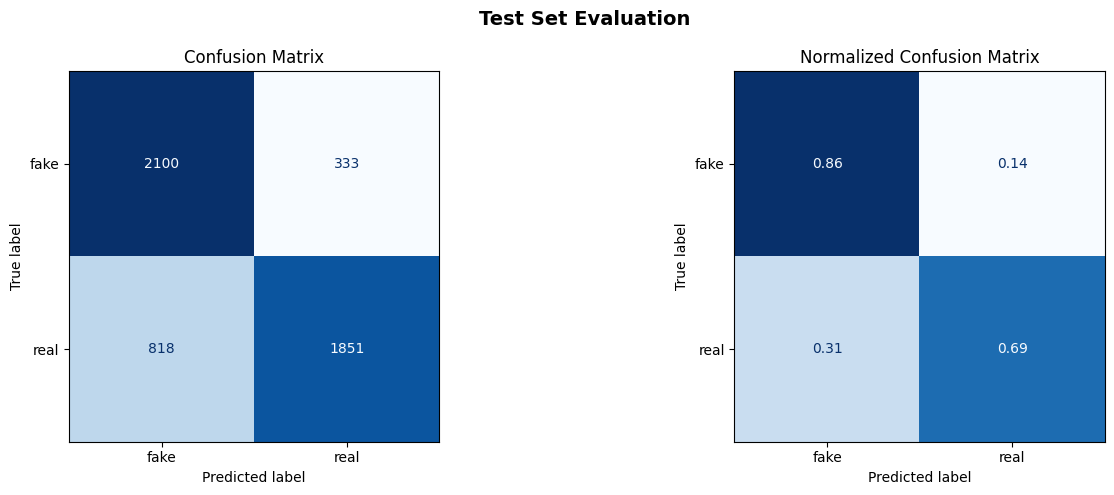

✅ Saved confusion_matrix.png


In [17]:
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test Set Evaluation", fontsize=14, fontweight="bold")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# Normalized confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=classes)
disp2.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150); plt.show()
print("✅ Saved confusion_matrix.png")

## 12. ROC Curve

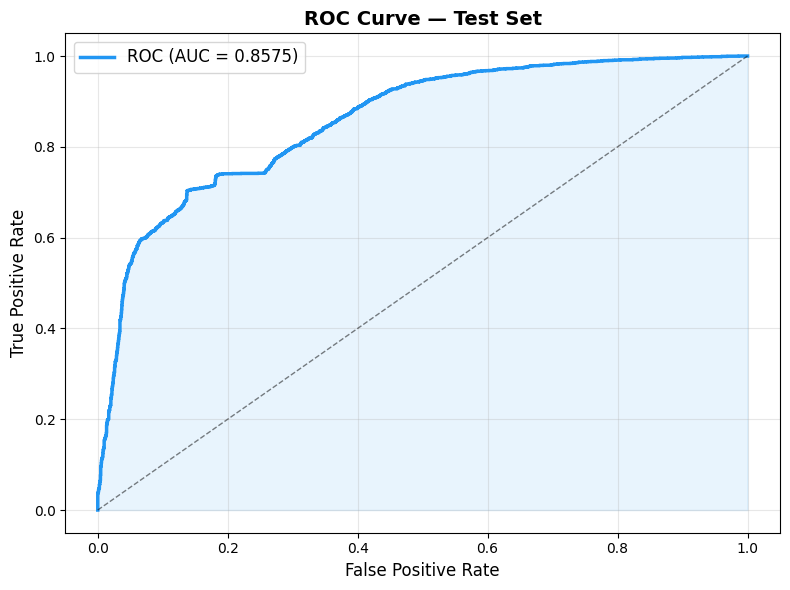

✅ Saved roc_curve.png


In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#2196F3", linewidth=2.5, label=f"ROC (AUC = {test_auc:.4f})")
plt.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5)
plt.fill_between(fpr, tpr, alpha=0.1, color="#2196F3")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Test Set", fontsize=14, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150); plt.show()
print("✅ Saved roc_curve.png")


## 13. Optimal Decision Threshold (Optional)

Val threshold search: 100%|██████████| 140/140 [00:34<00:00,  4.09it/s]


Best threshold on Val: 0.58  (F1=0.9003)
Test with threshold=0.58: Acc=77.07%  F1=0.7695


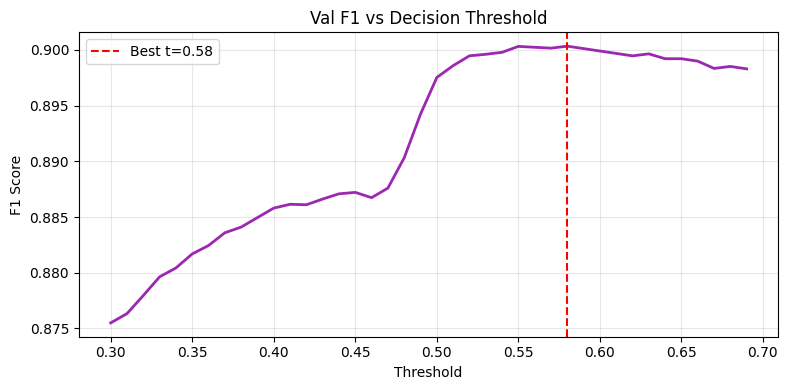

In [19]:
# Find threshold maximizing F1 on validation set
val_probs_all, val_labels_all = [], []
model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Val threshold search"):
        images = images.to(device)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()
        val_probs_all.extend(probs)
        val_labels_all.extend(labels.numpy().flatten().astype(int))

thresholds_scan = np.arange(0.30, 0.70, 0.01)
f1_scores = [f1_score(val_labels_all, (np.array(val_probs_all) >= t).astype(int)) for t in thresholds_scan]

best_thresh = thresholds_scan[np.argmax(f1_scores)]
print(f"Best threshold on Val: {best_thresh:.2f}  (F1={max(f1_scores):.4f})")

# Re-evaluate test with optimal threshold
preds_opt = (np.array(all_probs) >= best_thresh).astype(int)
acc_opt   = accuracy_score(all_labels, preds_opt)
f1_opt    = f1_score(all_labels, preds_opt, average="weighted")
print(f"Test with threshold={best_thresh:.2f}: Acc={acc_opt*100:.2f}%  F1={f1_opt:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds_scan, f1_scores, linewidth=2, color="#9C27B0")
plt.axvline(best_thresh, color="red", linestyle="--", label=f"Best t={best_thresh:.2f}")
plt.xlabel("Threshold"); plt.ylabel("F1 Score")
plt.title("Val F1 vs Decision Threshold"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("threshold_curve.png", dpi=120); plt.show()


## 14. Final Summary

In [20]:
print("\n" + "="*70)
print("  DEEPFAKE DETECTOR V4 — COMPLETE RESULTS SUMMARY")
print("="*70)

best_ep = int(np.argmin(val_losses))
print(f"  Best epoch (by val loss): {best_ep+1}")
print()
print(f"  TRAIN  | Loss={train_losses[best_ep]:.4f}  Acc={train_accs[best_ep]*100:.2f}%  AUC={train_aucs[best_ep]:.4f}")
print(f"  VAL    | Loss={val_losses[best_ep]:.4f}  Acc={val_accs[best_ep]*100:.2f}%  AUC={val_aucs[best_ep]:.4f}")
print(f"  TEST   | Loss={test_loss:.4f}  Acc={test_acc*100:.2f}%  AUC={test_auc:.4f}")
print()
print("  Architecture: EfficientNet-B4 + DeiT-Small + FFT Branch")
print("                + Gated Fusion + BiLSTM(256) + Deep Head")
print("="*70)



  DEEPFAKE DETECTOR V4 — COMPLETE RESULTS SUMMARY
  Best epoch (by val loss): 24

  TRAIN  | Loss=0.2358  Acc=86.33%  AUC=0.9063
  VAL    | Loss=0.4310  Acc=88.34%  AUC=0.9127
  TEST   | Loss=0.7034  Acc=77.44%  AUC=0.8575

  Architecture: EfficientNet-B4 + DeiT-Small + FFT Branch
                + Gated Fusion + BiLSTM(256) + Deep Head


## 15. Single-Image Inference

In [21]:
from PIL import Image as PILImage

def predict_image(model, image_path, device, threshold=0.5):
    """Predict real/fake for a single image path."""
    model.eval()
    transform = val_test_transforms
    img = PILImage.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(x)
        prob  = torch.sigmoid(logit).item()
        pred  = int(prob >= threshold)
    label = "FAKE" if pred == 1 else "REAL"
    conf  = prob if pred == 1 else 1 - prob
    print(f"  Prediction: {label}  (confidence={conf*100:.1f}%,  raw_prob={prob:.4f})")
    return pred, prob

# ── Example usage (change path as needed) ────────────────────────────────
pred, prob = predict_image(model, "/kaggle/input/datasets/fatahrahimi/dataset/content/processed_ffpp/test/real/01__walking_down_indoor_hall_disgust/0000.jpg", device)
print(f"Predicted: {pred}     Probability: {prob}")

  Prediction: REAL  (confidence=53.9%,  raw_prob=0.4610)
Predicted: 0     Probability: 0.46101608872413635


## 16. FGSM Attack Function

In [22]:
# -----------------------------
# FGSM Attack Function
# -----------------------------
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image


# -----------------------------
# Load best model
# -----------------------------
print("🔄 Loading best model weights …")
model.load_state_dict(torch.load(BEST_MODEL, map_location=device))

# Attack strength
epsilon = 0.03

all_probs, all_preds, all_labels = [], [], []
test_loss = 0.0


# -----------------------------
# FGSM Evaluation Loop
# -----------------------------
for images, labels in tqdm(test_loader, desc="FGSM Testing"):

    images = images.to(device)
    labels_f = labels.float().unsqueeze(1).to(device)

    # Enable gradient for input images
    images.requires_grad = True

    # IMPORTANT: RNN backward requires train mode
    model.train()

    # Forward pass
    logits = model(images)
    loss = criterion(logits, labels_f)

    # Zero gradients
    model.zero_grad()

    # Backprop to compute gradients
    loss.backward()

    data_grad = images.grad.data

    # Generate adversarial images
    adv_images = fgsm_attack(images, epsilon, data_grad)

    # Now switch to eval for testing
    model.eval()

    with torch.no_grad():
        adv_logits = model(adv_images)

        loss = criterion(adv_logits, labels_f)
        test_loss += loss.item()

        probs = torch.sigmoid(adv_logits).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)

    all_probs.extend(probs)
    all_preds.extend(preds)
    all_labels.extend(labels.cpu().numpy().flatten().astype(int))


# -----------------------------
# Metrics
# -----------------------------
test_loss /= len(test_loader)

test_acc = accuracy_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)
test_f1  = f1_score(all_labels, all_preds, average="weighted")


print("\n" + "="*60)
print("  FGSM ADVERSARIAL TEST RESULTS")
print("="*60)
print(f"  Epsilon:  {epsilon}")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc*100:.2f}%")
print(f"  AUC-ROC:  {test_auc:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print("="*60)


# -----------------------------
# Target check
# -----------------------------
if test_acc >= 0.95:
    print(f"  ✅ TARGET ACHIEVED: {test_acc*100:.2f}% ≥ 95%")
else:
    print(f"  ⚠️ Robustness Drop. Gap: {(0.95 - test_acc)*100:.2f}%")

🔄 Loading best model weights …


FGSM Testing: 100%|██████████| 160/160 [02:55<00:00,  1.09s/it]


  FGSM ADVERSARIAL TEST RESULTS
  Epsilon:  0.03
  Loss:     1.7533
  Accuracy: 58.55%
  AUC-ROC:  0.4754
  F1 Score: 0.5769
  ⚠️ Robustness Drop. Gap: 36.45%
